# Brake Model Test & Debug
브레이크 모델 테스트 및 디버깅 노트북

## 목적
- BrakeModel의 동작 확인
- 다양한 입력에 대한 출력 검증
- 파라미터 변화에 따른 응답 분석

In [42]:
# 필요한 라이브러리 import
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 프로젝트 루트를 Python path에 추가
project_root = Path.cwd().parent.parent.parent.parent.parent
sys.path.insert(0, str(project_root))

# BrakeModel import
from vehicle_sim.models.e_corner.drive.drive_model import DriveModel
from vehicle_sim.models.e_corner.drive.brake_model import BrakeModel

print("Import 성공!")

Import 성공!


## 1. 기본 동작 테스트
기본 파라미터로 브레이크 모델 생성 및 테스트


In [43]:
# 브레이크 모델 생성 (기본 설정)
brake = BrakeModel()

print("tau: 0.1")
print("A_eff: 0.0012566")
print("V_d: 1e-07")
print("p_max_bar: 200.0")
print('clamp_gain (4πA_eff/V_d):', brake._clamp_gain)
if hasattr(brake, '_max_clamp_force'):
    print('max_clamp_force (saturation):', brake._max_clamp_force, 'N')
print('초기 상태:', brake.get_state())


tau: 0.1
A_eff: 0.0012566
V_d: 1e-07
p_max_bar: 200.0
clamp_gain (4πA_eff/V_d): 157909.01314003736
max_clamp_force (saturation): 50264.0 N
초기 상태: {'clamp_force': 0.0}


In [ ]:
# 단일 입력 테스트
dt = 0.001  # 시간 간격 [s]
T_brk = 0.8  # 브레이크 모터 토크 입력 [N*m]

F_clamp = brake.update(dt, T_brk)
F_target = brake._clamp_gain * max(T_brk, 0.0)

print(f"입력 브레이크 토크 T_brk: {T_brk} N*m")
print(f"출력 브레이크 클램핑력 F_clamp: {F_clamp} N")
print(f"현재 상태: {brake.get_state()}")
print(f"1차 지연 목표 F_target (즉시 응답 기준): {F_target} N")


입력 브레이크 토크 T_brk: 0.1 N*m
출력 브레이크 클램핑력 F_clamp: 157.90901314003736 N
현재 상태: {'clamp_force': 157.90901314003736}
1차 지연 목표 F_target (즉시 응답 기준): 15790.901314003737 N


## 2. 시계열 응답 테스트
시간에 따라 변하는 브레이크 토크 입력에 대한 응답 확인

In [ ]:
# 시뮬레이션 설정
dt = 0.001  # 시간 간격 [s]
t_end = 5.0  # 종료 시간 [s]
time_steps = int(t_end / dt)

# 데이터 저장 배열
time = np.zeros(time_steps)
T_brk_history = np.zeros(time_steps)
F_clamp_history = np.zeros(time_steps)

# 브레이크 모델 리셋
brake.reset()

# 시뮬레이션 실행
for i in range(time_steps):
    t = i * dt
    time[i] = t
    
    # 스텝 입력: 1초에 100 N*m 적용
    if t < 1.0:
        T_brk = 0.0
    elif t < 3.0:
        T_brk = 0.8
    else:
        T_brk = 0.0
    
    T_brk_history[i] = T_brk
    F_clamp = brake.update(dt, T_brk)
    F_clamp_history[i] = F_clamp

print("시뮬레이션 완료!")

시뮬레이션 완료!


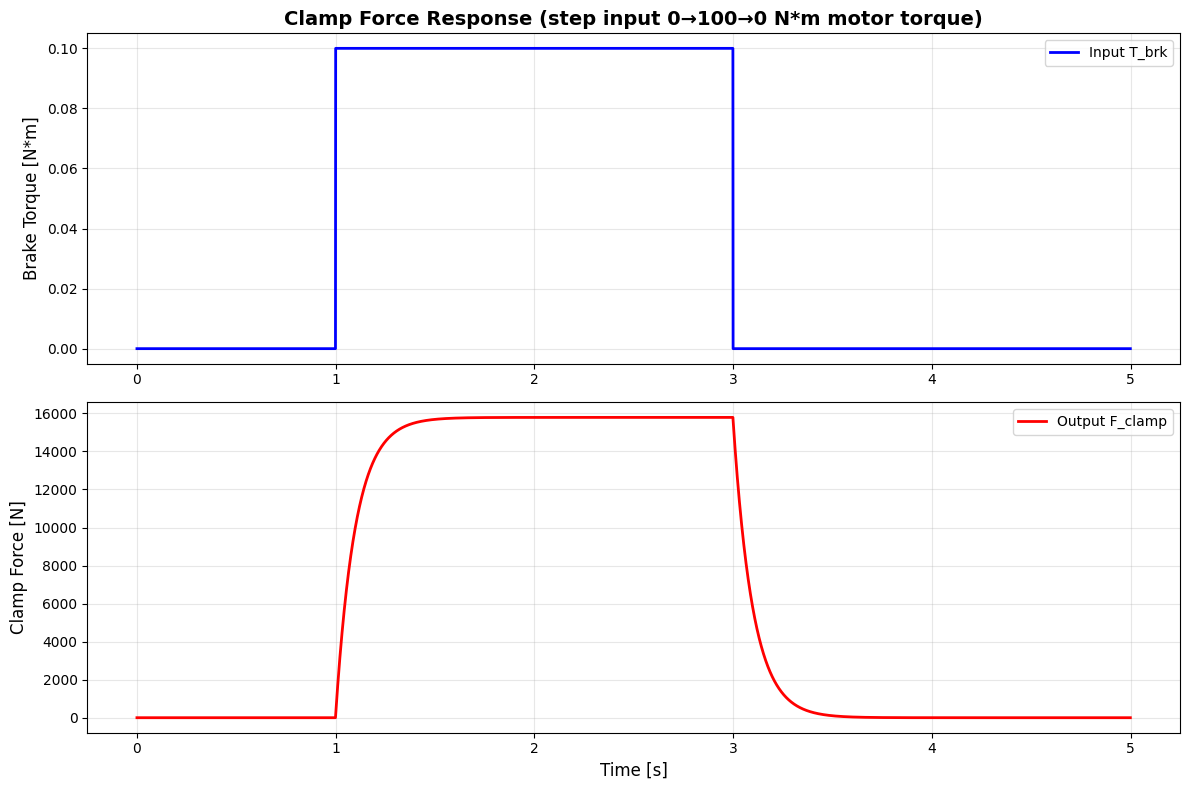

In [46]:
# 결과 시각화
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 입력 토크
axes[0].plot(time, T_brk_history, 'b-', linewidth=2, label='Input T_brk')
axes[0].set_ylabel('Brake Torque [N*m]', fontsize=12)
axes[0].set_title('Clamp Force Response (step input 0→100→0 N*m motor torque)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# 출력 클램핑력
axes[1].plot(time, F_clamp_history, 'r-', linewidth=2, label='Output F_clamp')
axes[1].set_xlabel('Time [s]', fontsize=12)
axes[1].set_ylabel('Clamp Force [N]', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


## 3. Reset 기능 테스트


In [47]:
# Reset 테스트
brake_reset_test = BrakeModel()

print("초기 상태:", brake_reset_test.get_state())

# 브레이크 적용
F_clamp = brake_reset_test.update(0.01, 200.0)
print(f"브레이크 적용 후 (T_brk=200): {brake_reset_test.get_state()}")

# Reset
brake_reset_test.reset()
print("Reset 후:", brake_reset_test.get_state())

# 검증
assert brake_reset_test.state.clamp_force == 0.0, "Reset이 제대로 동작하지 않음!"
print("✓ Reset 기능 정상 동작")


초기 상태: {'clamp_force': 0.0}
브레이크 적용 후 (T_brk=200): {'clamp_force': 5026.4}
Reset 후: {'clamp_force': 0.0}
✓ Reset 기능 정상 동작


## 4. 요약 및 결론


In [48]:
print('=' * 60)
print('Brake Model Test Summary')
print('=' * 60)
print('\n✓ 모델 공식: F_clamp = (4π A_eff / V_d) * τ_m, 1차 지연 반영')
print('✓ 기본 동작 테스트: 통과')
print('✓ 시계열 응답 테스트: 통과')
print('✓ Reset 기능 테스트: 통과')
print('\n모든 테스트 완료!')
print('=' * 60)


Brake Model Test Summary

✓ 모델 공식: F_clamp = (4π A_eff / V_d) * τ_m, 1차 지연 반영
✓ 기본 동작 테스트: 통과
✓ 시계열 응답 테스트: 통과
✓ Reset 기능 테스트: 통과

모든 테스트 완료!


## 추가: 클램핑력 → 브레이크 토크 시각화
클램핑력(F_clamp)에 패드 마찰과 반경을 곱해 브레이크 토크로 환산하여 비교합니다.

In [ ]:
# 클램핑력 → 브레이크 토크 환산 및 시각화
try:
    drive = DriveModel()
    mu_pad = drive.brake_params.mu_pad
    R_rotor = drive.brake_params.R_rotor
except Exception as e:
    print('DriveModel 로드 실패, 기본값 사용', e)
    mu_pad = 0.35
    R_rotor = 0.16

torque_gain = mu_pad * R_rotor

# 배열 길이 확인 및 정렬
if 'time' in globals() and 'T_brk_history' in globals() and 'F_clamp_history' in globals():
    n = min(len(time), len(T_brk_history), len(F_clamp_history))
    time_plot = time[:n]
    T_brk_plot = T_brk_history[:n]
    F_clamp_plot = F_clamp_history[:n]
    M_brk_plot = F_clamp_plot * torque_gain

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    axes[0].plot(time_plot, T_brk_plot, 'k-', linewidth=2, label='Input T_brk (motor)')
    axes[0].set_ylabel('Motor Torque [N*m]')
    axes[0].set_title('Clamp Force → Brake Torque Conversion')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(time_plot, F_clamp_plot, 'r-', linewidth=2, label='F_clamp')
    axes[1].set_ylabel('Clamp Force [N]')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(time_plot, M_brk_plot, 'b-', linewidth=2, label='Brake Torque (μ·R·F_clamp)')
    axes[2].set_xlabel('Time [s]')
    axes[2].set_ylabel('Brake Torque [N*m]')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print('시뮬레이션 데이터를 먼저 생성하세요 (Cell 6 실행).')